[SAVED] night_sky_brightness_2026-06-29_all_bands_grid.png


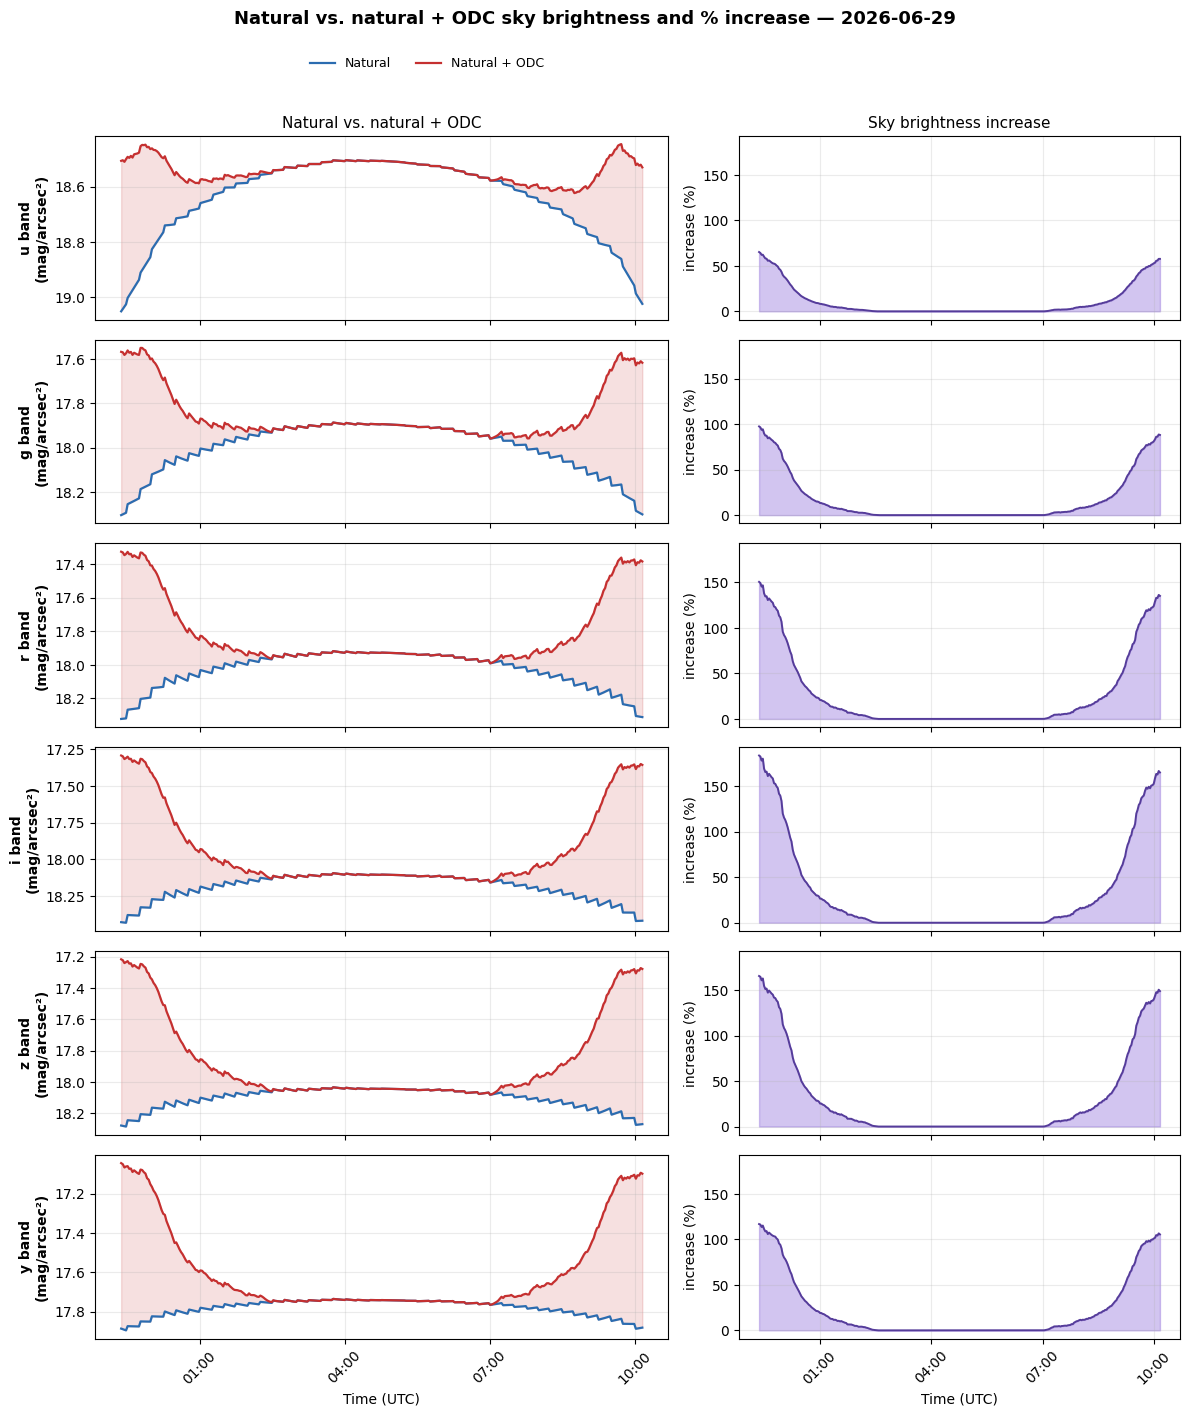


band     peak % incr   mean % incr
----------------------------------
u              65.2%         10.8%
g              97.5%           17%
r               151%         26.3%
i               184%         32.9%
z               165%         30.5%
y               117%         22.3%


In [ ]:
"""
plot_all_bands_sky_brightness.py
─────────────────────────────────────────────────────────────────────────────
ONE figure covering all six LSST filters (u/g/r/i/z/y), with only two
things per filter:
    left       -> natural vs. natural+ODC sky brightness (mag/arcsec^2)
    right      -> sky brightness increase (%)

LAYOUT = "grid"    : one ROW per filter, 2 columns (default). Left =
                     natural vs. natural+ODC brightness, right = %
                     increase. With SHARE_PCT_Y=True the % column shares
                     one y-axis so bands are directly comparable (small
                     bands then look flat next to big ones); the
                     brightness column never shares (each band's natural
                     sky sits at a different absolute mag).
LAYOUT = "overlay" : 2 stacked panels, every filter overlaid in its own
                     colour (top: solid = natural+ODC, dashed = natural).

Reads night_sky_brightness_{DATE_STR}_{band}.csv (same naming as
run_step10_all_bands.sbatch). Missing bands are skipped with a warning.
Works the same in a notebook cell or from the command line (no argv).
"""

import os
import sys

import matplotlib
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Only force a non-interactive backend outside notebooks; forcing Agg inside
# Jupyter would silence the inline display.
try:
    get_ipython()  # noqa: F821
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False
if (not IN_NOTEBOOK and not os.environ.get("DISPLAY")
        and sys.platform.startswith("linux")):
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ── Edit these ───────────────────────────────────────────────────────────
DATE_STR = "2026-07-15" #For new moon day
#DATE_STR = "2026-06-29" For full moon day
BANDS = ["u", "g", "r", "i", "z", "y"]
LAYOUT = "grid"          # "grid" or "overlay"
SHARE_PCT_Y = True       # grid only: same % y-scale on every row
# ─────────────────────────────────────────────────────────────────────────

BAND_COLORS = {"u": "#6a3d9a", "g": "#33a02c", "r": "#e31a1c",
               "i": "#ff7f00", "z": "#a65628", "y": "#4d4d4d"}


def first_present(df, options):
    for c in options:
        if c in df.columns:
            return c
    return None


def load_band(band):
    path = f"night_sky_brightness_{DATE_STR}_{band}.csv"
    if not os.path.isfile(path):
        print(f"[WARN] Not found, skipping: {path}")
        return None
    df = pd.read_csv(path).sort_values("mjd").reset_index(drop=True)
    df["time"] = pd.to_datetime(df["mjd"], unit="D",
                                origin=pd.Timestamp("1858-11-17"))
    nat = first_present(df, ["mu_natural", "mu_natural_avg"])
    comb = first_present(df, ["mu_combined", "mu_combined_avg"])
    if nat is None or comb is None:
        print(f"[WARN] {path} has no natural/combined columns, skipping")
        return None
    df = df.rename(columns={nat: "nat", comb: "comb"})
    return df


def style_time_axis(ax):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params(axis="x", rotation=45)


def plot_grid(data):
    """One ROW per filter, two COLUMNS: left = natural vs. natural+ODC
    brightness, right = % increase. Legend lives in one figure-level strip
    above the plots (not inside any band's axes, where it covers data)."""
    n = len(data)
    fig, axes = plt.subplots(n, 2, figsize=(12, 2.4 * n), sharex=True,
                             squeeze=False,
                             gridspec_kw={"width_ratios": [1.3, 1]})
    for i, (band, df) in enumerate(data.items()):
        ax_b, ax_p = axes[i, 0], axes[i, 1]
        line_nat, = ax_b.plot(df["time"], df["nat"], color="#2b6cb0", lw=1.6)
        line_comb, = ax_b.plot(df["time"], df["comb"], color="#c53030", lw=1.6)
        ax_b.fill_between(df["time"], df["nat"], df["comb"],
                          color="#c53030", alpha=0.15)
        ax_b.invert_yaxis()   # brighter (smaller mag) = higher
        ax_b.set_ylabel(f"{band} band\n(mag/arcsec²)", fontweight="bold")
        ax_b.grid(alpha=0.25)

        ax_p.fill_between(df["time"], 0, df["pct_increase"],
                          color="#805ad5", alpha=0.35)
        ax_p.plot(df["time"], df["pct_increase"], color="#553c9a", lw=1.4)
        ax_p.set_ylabel("increase (%)")
        ax_p.grid(alpha=0.25)
        if SHARE_PCT_Y and i > 0:
            ax_p.sharey(axes[0, 1])   # comparable % scale across bands

        if i == 0:
            ax_b.set_title("Natural vs. natural + ODC", fontsize=11)
            ax_p.set_title("Sky brightness increase", fontsize=11)
            fig.legend([line_nat, line_comb], ["Natural", "Natural + ODC"],
                       loc="upper center", bbox_to_anchor=(0.36, 0.955),
                       ncol=2, fontsize=9, frameon=False)

    for ax in axes[-1]:
        ax.set_xlabel("Time (UTC)")
        style_time_axis(ax)
    return fig


def plot_overlay(data):
    fig, (ax_b, ax_p) = plt.subplots(2, 1, figsize=(11, 9), sharex=True,
                                     gridspec_kw={"height_ratios": [1.3, 1]})
    for band, df in data.items():
        c = BAND_COLORS.get(band, None)
        ax_b.plot(df["time"], df["comb"], color=c, lw=1.6, label=f"{band}")
        ax_b.plot(df["time"], df["nat"], color=c, lw=1.2, ls="--", alpha=0.8)
        ax_p.plot(df["time"], df["pct_increase"], color=c, lw=1.6,
                  label=f"{band}")
    ax_b.invert_yaxis()
    ax_b.set_ylabel("Sky brightness (mag/arcsec²)\nsolid = natural + ODC, "
                    "dashed = natural")
    ax_b.legend(title="band", ncol=6, fontsize=9, loc="lower center")
    ax_p.set_ylabel("Sky brightness increase (%)")
    ax_p.set_xlabel("Time (UTC)")
    for ax in (ax_b, ax_p):
        ax.grid(alpha=0.25)
    style_time_axis(ax_p)
    return fig


def main():
    data = {}
    for band in BANDS:
        df = load_band(band)
        if df is not None:
            data[band] = df
    if not data:
        raise FileNotFoundError(
            f"No night_sky_brightness_{DATE_STR}_<band>.csv files found in "
            f"{os.getcwd()} -- check DATE_STR/BANDS.")

    fig = plot_grid(data) if LAYOUT == "grid" else plot_overlay(data)
    fig.suptitle(f"Natural vs. natural + ODC sky brightness and % "
                 f"increase — {DATE_STR}", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.94])

    out = f"night_sky_brightness_{DATE_STR}_all_bands_{LAYOUT}.png"
    fig.savefig(out, dpi=180)
    print(f"[SAVED] {out}")
    if matplotlib.get_backend().lower() != "agg":
        plt.show()
    else:
        plt.close(fig)

    print(f"\n{'band':<6}{'peak % incr':>14}{'mean % incr':>14}")
    print("-" * 34)
    for band, df in data.items():
        print(f"{band:<6}{df['pct_increase'].max():>13.3g}%"
              f"{df['pct_increase'].mean():>13.3g}%")


main()